In [2]:
import sqlite3
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from hybrid_common import (
    build_geo_dict_kdtree, stream_events_with_truth,compute_pca_features,PCA_FEATURE_NAMES,
    event_to_string_graph, GNN_FEATURE_NAMES,
)

In [3]:
def collect_pca_features_from_dir(db_dir, n_files=5, max_events_per_file=None,
                                   charge_threshold=0.1, pattern="*.db"):
    db_paths = sorted(glob.glob(os.path.join(db_dir, pattern)))[:n_files]
    if not db_paths:
        raise FileNotFoundError(f"No DB files matching {pattern} in {db_dir}")

    rows_out  = []
    n_total   = 0
    n_invalid = 0

    for db_path in db_paths:
        n_this_file = 0
        for eid, rows, meta in stream_events_with_truth(db_path):
            if max_events_per_file and n_this_file >= max_events_per_file:
                break
            n_total += 1
            n_this_file += 1

            feats = compute_pca_features(
                rows, kd_tree, string_ids_geo, meta=meta,
                charge_threshold=charge_threshold,
            )
            if feats["is_valid"]:
                feats["event_no"] = eid
                feats["db_file"]  = os.path.basename(db_path)
                rows_out.append(feats)
            else:
                n_invalid += 1

    df = pd.DataFrame(rows_out)
    print(f"{db_dir}")
    print(f"  files loaded: {len(db_paths)}")
    print(f"  events seen:  {n_total}")
    print(f"  valid:        {len(df)} ({100 * len(df) / max(n_total, 1):.1f}%)")
    print(f"  invalid:      {n_invalid}")
    return df

In [20]:
NUTAU_DIR = "/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_train"
NUE_DIR   = "/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nue_train"  # adjust

geo = pd.read_csv("/mnt/scratch/baburish/doublepulse/gnn/Analysis/geometry_clean.csv")
kd_tree, string_ids_geo = build_geo_dict_kdtree(geo)

df_tau = collect_pca_features_from_dir(NUTAU_DIR, n_files=20, pattern='nutau_gemini_ftp_65TeV_*.db')
df_nue = collect_pca_features_from_dir(NUE_DIR, n_files=20, pattern='nue_gemini_ftp_65TeV_*.db')
print(f"Collected {len(df_tau)} nutau events and {len(df_nue)} nue events.")
df_tau["label"] = "nutau"
df_nue["label"] = "nue"
df_all = pd.concat([df_tau, df_nue], ignore_index=True)


/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_train
  files loaded: 20
  events seen:  1785
  valid:        1707 (95.6%)
  invalid:      78
/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nue_train
  files loaded: 20
  events seen:  2523
  valid:        2412 (95.6%)
  invalid:      111
Collected 1707 nutau events and 2412 nue events.


In [56]:
def attach_primary_energy(df_feats, db_dir):
    """Join primary_energy onto a PCA-features dataframe via (db_file, event_no)."""
    energies = []
    for db_file in df_feats["db_file"].unique():
        p = os.path.join(db_dir, db_file)
        c = sqlite3.connect(p)
        df_e = pd.read_sql_query("SELECT event_no, primary_energy FROM truth;", c)
        c.close()
        df_e["db_file"] = db_file
        energies.append(df_e)

    df_energy_all = pd.concat(energies, ignore_index=True)
    return df_feats.merge(df_energy_all, on=["db_file", "event_no"], how="left")


df_tau = attach_primary_energy(df_tau, NUTAU_DIR)
df_nue = attach_primary_energy(df_nue, NUE_DIR)

print(f"tau missing energy after merge: {df_tau['primary_energy'].isna().sum()}")
print(f"nue missing energy after merge: {df_nue['primary_energy'].isna().sum()}")

tau missing energy after merge: 0
nue missing energy after merge: 0


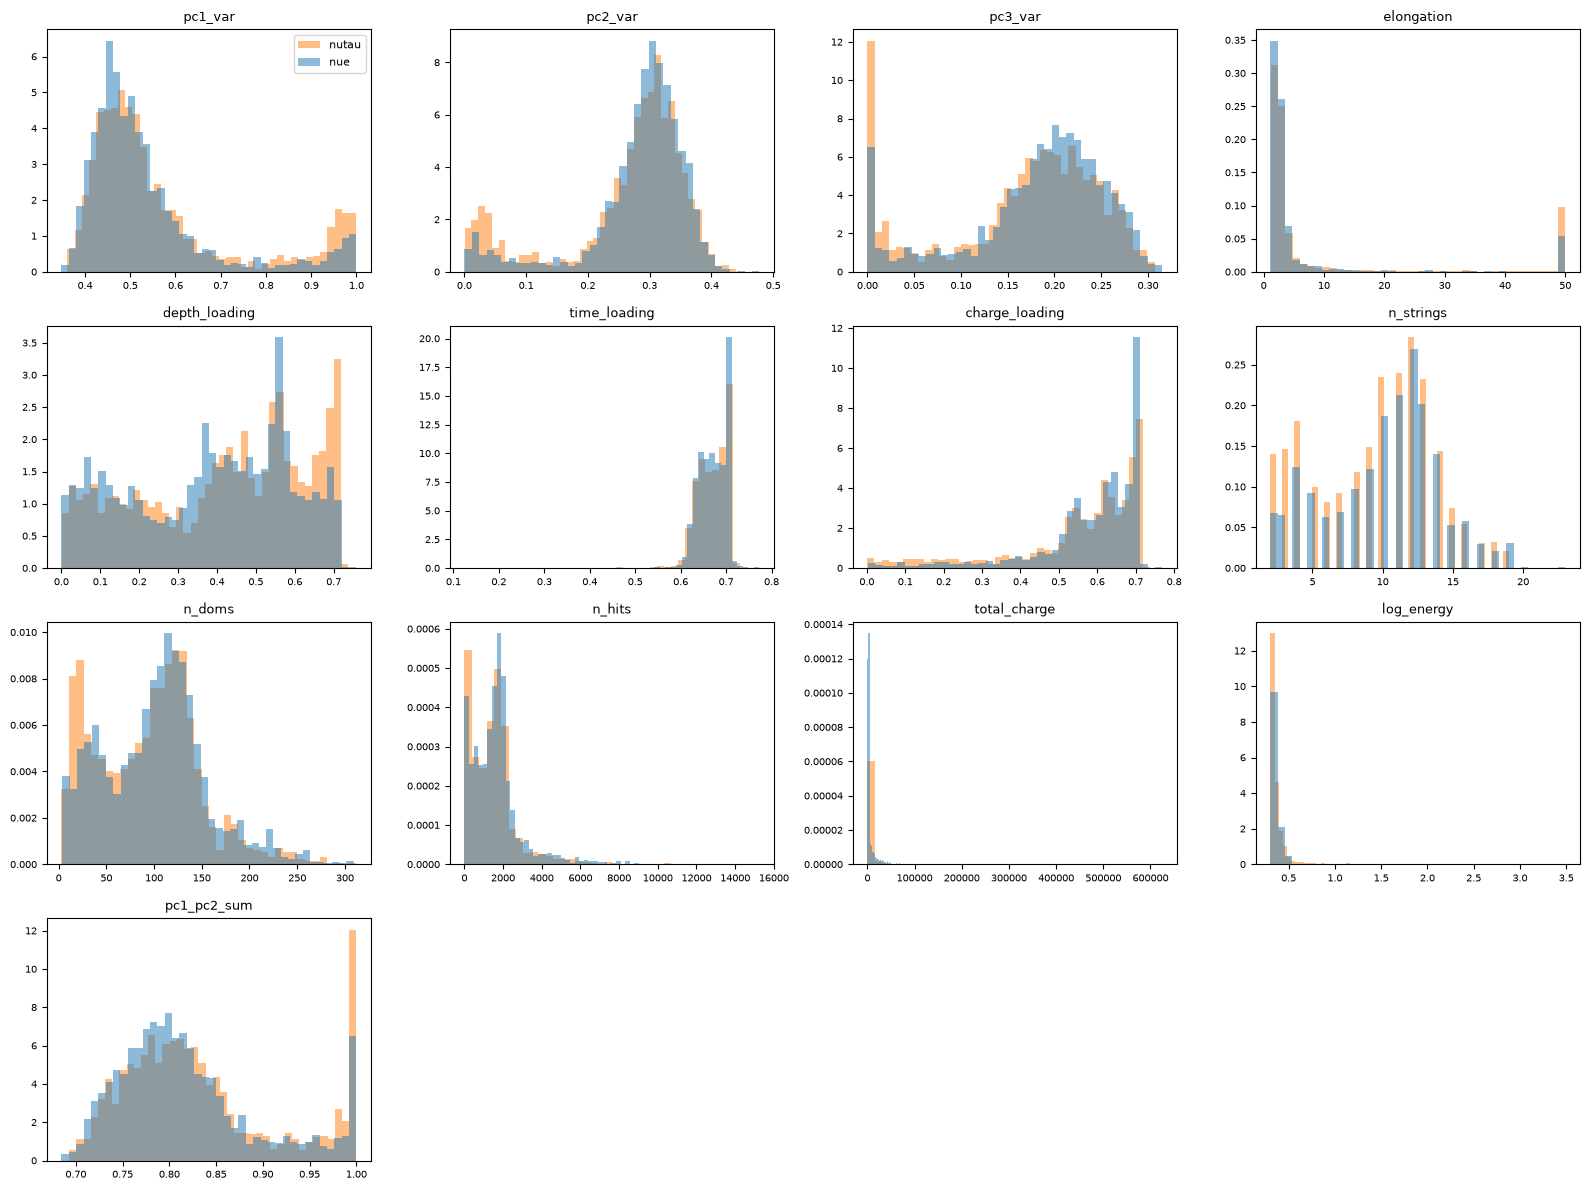

In [21]:
n_feats = len(PCA_FEATURE_NAMES)
ncols = 4
nrows = int(np.ceil(n_feats / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for i, feat in enumerate(PCA_FEATURE_NAMES):
    ax = axes[i]
    ax.hist(df_tau[feat], bins=40, alpha=0.5, label="nutau", density=True, color="tab:orange")
    ax.hist(df_nue[feat], bins=40, alpha=0.5, label="nue", density=True, color="tab:blue")
    ax.set_title(feat, fontsize=9)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=8)
for j in range(n_feats, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import roc_auc_score

# quantify separation for pc1_var, pc2_var, pc3_var (and full set for context)
features_to_check = ["pc1_var", "pc2_var", "pc3_var", "elongation", "pc1_pc2_sum"]

y = (df_all["label"] == "nutau").astype(int)

results = []
for feat in features_to_check:
    vals_tau = df_tau[feat].values
    vals_nue = df_nue[feat].values

    # AUC: how well this single feature alone separates the classes
    auc = roc_auc_score(y, df_all[feat])
    auc_directionless = max(auc, 1 - auc)

    # KS test: are the two distributions statistically different
    ks_stat, ks_pval = stats.ks_2samp(vals_tau, vals_nue)

    # basic separation stats
    mean_tau, mean_nue = vals_tau.mean(), vals_nue.mean()
    std_tau, std_nue   = vals_tau.std(), vals_nue.std()
    # Cohen's d: standardized mean difference
    pooled_std = np.sqrt((std_tau**2 + std_nue**2) / 2)
    cohens_d = (mean_tau - mean_nue) / pooled_std if pooled_std > 0 else np.nan

    results.append({
        "feature": feat,
        "auc": auc_directionless,
        "ks_stat": ks_stat,
        "ks_pval": ks_pval,
        "mean_tau": mean_tau,
        "mean_nue": mean_nue,
        "cohens_d": cohens_d,
    })

df_sep = pd.DataFrame(results).sort_values("auc", ascending=False)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print(df_sep)

       feature    auc  ks_stat  ks_pval  mean_tau  mean_nue  cohens_d
3   elongation 0.5265   0.0652   0.0940    9.7222    8.8240    0.0582
0      pc1_var 0.5262   0.0608   0.1407    0.5724    0.5619    0.0605
2      pc3_var 0.5240   0.0556   0.2165    0.1658    0.1719   -0.0738
4  pc1_pc2_sum 0.5236   0.0556   0.2165    0.8342    0.8281    0.0738
1      pc2_var 0.5134   0.0410   0.5747    0.2619    0.2662   -0.0422


In [7]:
from hybrid_common import PCA_FEATURE_NAMES

results_all = []
for feat in PCA_FEATURE_NAMES:
    vals_tau = df_tau[feat].values
    vals_nue = df_nue[feat].values
    auc = roc_auc_score(y, df_all[feat])
    ks_stat, ks_pval = stats.ks_2samp(vals_tau, vals_nue)
    pooled_std = np.sqrt((vals_tau.std()**2 + vals_nue.std()**2) / 2)
    cohens_d = (vals_tau.mean() - vals_nue.mean()) / pooled_std if pooled_std > 0 else np.nan

    results_all.append({
        "feature": feat,
        "auc": max(auc, 1 - auc),
        "ks_stat": ks_stat,
        "ks_pval": ks_pval,
        "cohens_d": cohens_d,
    })

df_sep_all = pd.DataFrame(results_all).sort_values("auc", ascending=False)
print(df_sep_all.to_string(index=False))

       feature    auc  ks_stat  ks_pval  cohens_d
    elongation 0.5265   0.0652   0.0940    0.0582
       pc1_var 0.5262   0.0608   0.1407    0.0605
  time_loading 0.5253   0.0628   0.1171    0.0527
       pc3_var 0.5240   0.0556   0.2165   -0.0738
   pc1_pc2_sum 0.5236   0.0556   0.2165    0.0738
    log_energy 0.5205   0.0630   0.1156   -0.0888
       pc2_var 0.5134   0.0410   0.5747   -0.0422
  total_charge 0.5107   0.0391   0.6348    0.0406
 depth_loading 0.5097   0.0489   0.3535    0.0154
charge_loading 0.5079   0.0506   0.3144   -0.0810
        n_hits 0.5064   0.0344   0.7824   -0.0333
        n_doms 0.5045   0.0332   0.8155   -0.0278
     n_strings 0.5010   0.0257   0.9683   -0.0072


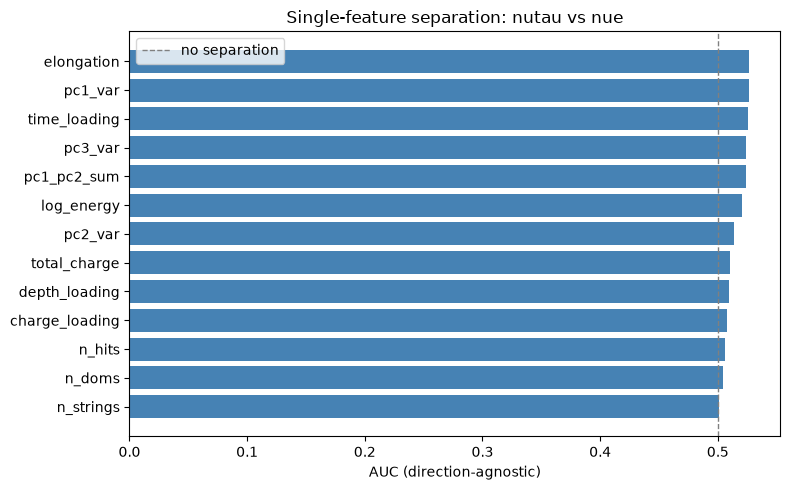

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
df_plot = df_sep_all.sort_values("auc")
ax.barh(df_plot["feature"], df_plot["auc"], color="steelblue")
ax.axvline(0.5, color="gray", linestyle="--", lw=1, label="no separation")
ax.set_xlabel("AUC (direction-agnostic)")
ax.set_title("Single-feature separation: nutau vs nue")
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
for feat in ["elongation", "pc1_var", "pc3_var", "depth_loading", "charge_loading"]:
    print(f"\n{feat}")
    print(stratified_auc(df_all, feat).to_string(index=False))


elongation
              bin  n_tau  n_nue    auc
   (3.999, 671.5]    493    537 0.5769
  (671.5, 1528.0]    436    596 0.5134
 (1528.0, 1984.5]    391    636 0.5171
(1984.5, 15249.0]    387    643 0.5460

pc1_var
              bin  n_tau  n_nue    auc
   (3.999, 671.5]    493    537 0.5751
  (671.5, 1528.0]    436    596 0.5175
 (1528.0, 1984.5]    391    636 0.5090
(1984.5, 15249.0]    387    643 0.5331

pc3_var
              bin  n_tau  n_nue    auc
   (3.999, 671.5]    493    537 0.5714
  (671.5, 1528.0]    436    596 0.5122
 (1528.0, 1984.5]    391    636 0.5180
(1984.5, 15249.0]    387    643 0.5446

depth_loading
              bin  n_tau  n_nue    auc
   (3.999, 671.5]    493    537 0.5946
  (671.5, 1528.0]    436    596 0.5160
 (1528.0, 1984.5]    391    636 0.5095
(1984.5, 15249.0]    387    643 0.5342

charge_loading
              bin  n_tau  n_nue    auc
   (3.999, 671.5]    493    537 0.5871
  (671.5, 1528.0]    436    596 0.5082
 (1528.0, 1984.5]    391    636 0.5058
(19

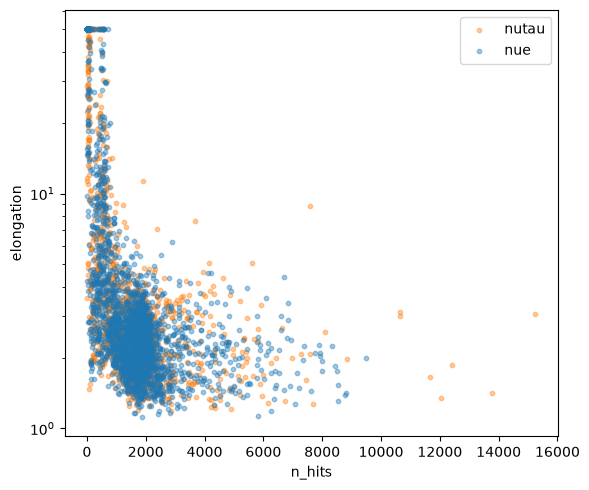

In [23]:
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(df_tau["n_hits"], df_tau["elongation"], alpha=0.4, s=10, label="nutau", color="tab:orange")
ax.scatter(df_nue["n_hits"], df_nue["elongation"], alpha=0.4, s=10, label="nue", color="tab:blue")
ax.set_xlabel("n_hits")
ax.set_ylabel("elongation")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# bin by n_hits and check if elongation separation holds within each size bin
df_all["n_hits_bin"] = pd.qcut(df_all["n_hits"], q=4, duplicates="drop")

for bin_name, group in df_all.groupby("n_hits_bin"):
    g_tau = group[group["label"] == "nutau"]["elongation"]
    g_nue = group[group["label"] == "nue"]["elongation"]
    if len(g_tau) < 5 or len(g_nue) < 5:
        continue
    y_bin = (group["label"] == "nutau").astype(int)
    auc_bin = roc_auc_score(y_bin, group["elongation"])
    print(f"{bin_name}: n_tau={len(g_tau)} n_nue={len(g_nue)}  elongation AUC={max(auc_bin, 1-auc_bin):.3f}")

(3.999, 671.5]: n_tau=493 n_nue=537  elongation AUC=0.577
(671.5, 1528.0]: n_tau=436 n_nue=596  elongation AUC=0.513
(1528.0, 1984.5]: n_tau=391 n_nue=636  elongation AUC=0.517
(1984.5, 15249.0]: n_tau=387 n_nue=643  elongation AUC=0.546


In [25]:
def stratified_auc(df, feature, size_col="n_hits", q=4):
    df = df.copy()
    df["_bin"] = pd.qcut(df[size_col], q=q, duplicates="drop")
    rows = []
    for bin_name, group in df.groupby("_bin"):
        n_tau = (group["label"] == "nutau").sum()
        n_nue = (group["label"] == "nue").sum()
        if n_tau < 5 or n_nue < 5:
            continue
        y_bin = (group["label"] == "nutau").astype(int)
        auc = roc_auc_score(y_bin, group[feature])
        rows.append({"bin": str(bin_name), "n_tau": n_tau, "n_nue": n_nue,
                      "auc": max(auc, 1 - auc)})
    return pd.DataFrame(rows)

for feat in ["elongation", "pc3_var", "pc1_pc2_sum", "pc1_var", "depth_loading", "charge_loading"]:
    print(f"\n{feat}")
    print(stratified_auc(df_all, feat).to_string(index=False))


elongation
              bin  n_tau  n_nue    auc
   (3.999, 671.5]    493    537 0.5769
  (671.5, 1528.0]    436    596 0.5134
 (1528.0, 1984.5]    391    636 0.5171
(1984.5, 15249.0]    387    643 0.5460

pc3_var
              bin  n_tau  n_nue    auc
   (3.999, 671.5]    493    537 0.5714
  (671.5, 1528.0]    436    596 0.5122
 (1528.0, 1984.5]    391    636 0.5180
(1984.5, 15249.0]    387    643 0.5446

pc1_pc2_sum
              bin  n_tau  n_nue    auc
   (3.999, 671.5]    493    537 0.5677
  (671.5, 1528.0]    436    596 0.5122
 (1528.0, 1984.5]    391    636 0.5180
(1984.5, 15249.0]    387    643 0.5446

pc1_var
              bin  n_tau  n_nue    auc
   (3.999, 671.5]    493    537 0.5751
  (671.5, 1528.0]    436    596 0.5175
 (1528.0, 1984.5]    391    636 0.5090
(1984.5, 15249.0]    387    643 0.5331

depth_loading
              bin  n_tau  n_nue    auc
   (3.999, 671.5]    493    537 0.5946
  (671.5, 1528.0]    436    596 0.5160
 (1528.0, 1984.5]    391    636 0.5095
(1984.

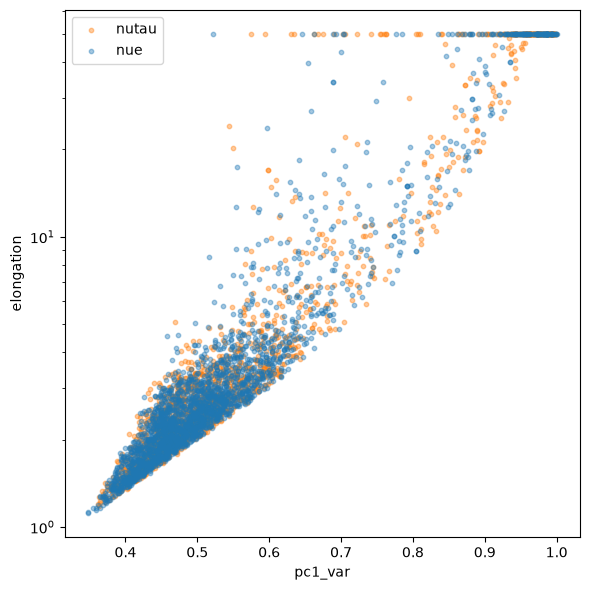

In [26]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df_tau["pc1_var"], df_tau["elongation"], s=10, alpha=0.4, label="nutau", color="tab:orange")
ax.scatter(df_nue["pc1_var"], df_nue["elongation"], s=10, alpha=0.4, label="nue", color="tab:blue")
ax.set_xlabel("pc1_var")
ax.set_ylabel("elongation")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

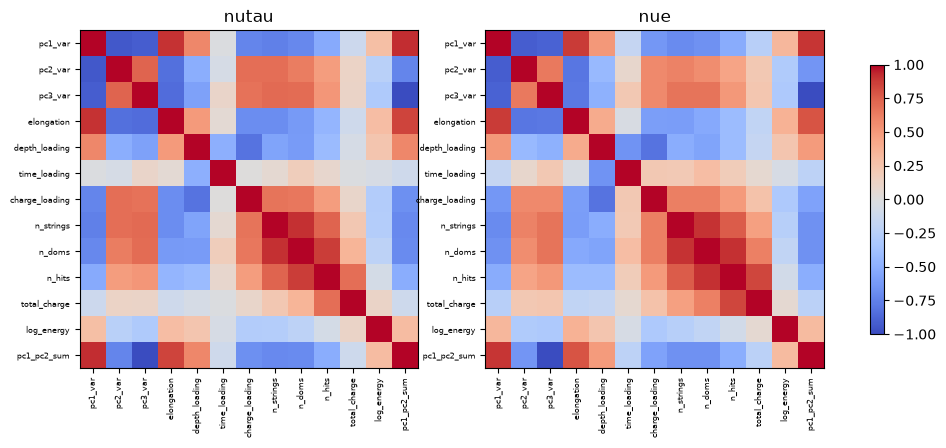

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, df, name in zip(axes, [df_tau, df_nue], ["nutau", "nue"]):
    corr = df[PCA_FEATURE_NAMES].corr()
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(n_feats)); ax.set_xticklabels(PCA_FEATURE_NAMES, rotation=90, fontsize=6)
    ax.set_yticks(range(n_feats)); ax.set_yticklabels(PCA_FEATURE_NAMES, fontsize=6)
    ax.set_title(name)
fig.colorbar(im, ax=axes, shrink=0.7)
plt.show()

In [28]:
def inspect_graphs(db_path, n_events=5, charge_threshold=0.1):
    graphs = []
    for eid, rows, meta in stream_events_with_truth(db_path):
        if len(graphs) >= n_events:
            break
        g = event_to_string_graph(
            rows, kd_tree, string_ids_geo, meta=meta,
            charge_threshold=charge_threshold,
        )
        graphs.append((eid, g))
    return graphs



nutau_db_paths = sorted(glob.glob(os.path.join(NUTAU_DIR, "nutau_gemini_ftp_65TeV_*.db")))
nutau_db = nutau_db_paths[0]
print(nutau_db)

graphs = inspect_graphs(nutau_db, n_events=5)

for eid, g in graphs:
    print(f"event_no={eid}  x.shape={tuple(g.x.shape)}  edge_index.shape={tuple(g.edge_index.shape)}")
    df_feats = pd.DataFrame(g.x.numpy(), columns=GNN_FEATURE_NAMES)
    print(df_feats)
    print()

/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_train/nutau_gemini_ftp_65TeV_lowerbound_skimmed_chunk_022633.000945_0000.db_train.db
event_no=0  x.shape=(9, 14)  edge_index.shape=(2, 72)
   str_x  str_y  z_centroid  z_asym  t_mean  t_asym  q_log  n_doms  t_spread  \
0 0.6601 0.2544     -0.2918  1.0000  2.8580 -1.0000 0.8650  0.0167    0.0000   
1 0.5146 0.4233     -0.4414  0.0714  2.5648 -0.9897 4.9495  0.4000    0.3194   
2 0.7647 0.4778     -0.1785 -0.0273  2.0642 -0.6638 5.9004  0.4333    0.4864   
3 1.0105 0.5158      0.1185  0.4722  2.2753 -0.8735 2.8449  0.1000    0.3963   
4 0.3489 0.6311     -0.4258  0.2403  2.4648 -0.9784 5.2155  0.4000    0.3558   
5 0.6068 0.6713     -0.2493 -0.5956  0.7920  0.8914 9.7102  0.5333    0.6830   
6 0.8595 0.7020      0.0163  0.3563  1.0574  0.5378 7.3122  0.4667    0.7490   
7 0.4492 0.8647     -0.1764  0.0007  1.9924 -0.6256 6.1832  0.4667    0.5272   
8 0.6769 0.9274      0.0186  0.3808  1.0452  0.5278 7.3803  0.4333    0.7795   

  

In [29]:
def graph_stats(db_path, n_events=200, charge_threshold=0.1):
    n_fallback  = 0  # x.shape[0] == 1, edge_index empty -> _fallback() triggered
    node_counts = []
    all_feats   = []

    n_seen = 0
    for eid, rows, meta in stream_events_with_truth(db_path):
        if n_seen >= n_events:
            break
        n_seen += 1
        g = event_to_string_graph(rows, kd_tree, string_ids_geo, meta=meta,
                                   charge_threshold=charge_threshold)
        if g.x.shape[0] == 1 and g.edge_index.shape[1] == 0:
            n_fallback += 1
            continue
        node_counts.append(g.x.shape[0])
        all_feats.append(g.x.numpy())

    all_feats = np.concatenate(all_feats, axis=0)
    print(f"events seen:      {n_seen}")
    print(f"fallback graphs:  {n_fallback} ({100*n_fallback/n_seen:.1f}%)")
    print(f"nodes/graph:      min={min(node_counts)} max={max(node_counts)} mean={np.mean(node_counts):.1f}")
    print(f"NaN in features:  {np.isnan(all_feats).sum()}")
    print(f"Inf in features:  {np.isinf(all_feats).sum()}")

    df = pd.DataFrame(all_feats, columns=GNN_FEATURE_NAMES)
    print(df.describe().T[["mean", "std", "min", "max"]])
    return df


df_feat_stats = graph_stats(nutau_db, n_events=200)

events seen:      18
fallback graphs:  2 (11.1%)
nodes/graph:      min=6 max=19 mean=13.2
NaN in features:  0
Inf in features:  0
                       mean    std     min     max
str_x               -0.0135 0.5733 -1.1418  1.1527
str_y                0.1586 0.5300 -1.0029  1.0190
z_centroid          -0.2561 0.5947 -0.9726  0.6946
z_asym               0.0600 0.3425 -0.7575  1.0000
t_mean               2.0642 0.7030  0.4289  3.0000
t_asym              -0.5043 0.6893 -1.0000  0.9674
q_log                6.6806 3.1298  0.3887 12.0650
n_doms               0.2615 0.1208  0.0167  0.6000
t_spread             0.3851 0.2068  0.0000  0.8982
z_rel               -0.0058 0.0697 -0.2323  0.3276
t_first              1.4019 0.8719  0.0000  3.0000
q_frac               0.0755 0.1562  0.0000  0.9750
distance_to_cascade  0.6832 0.2380  0.1044  1.0891
log_energy           0.6058 0.1090  0.3839  0.8546


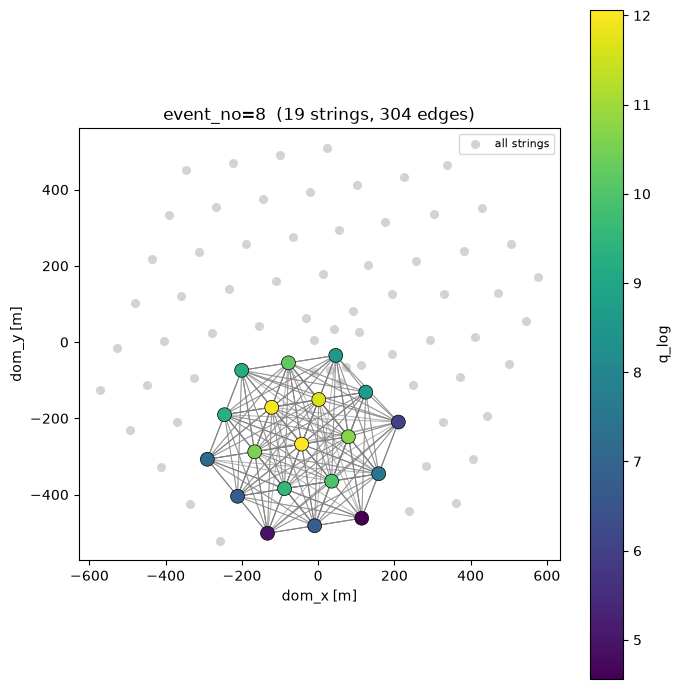

In [30]:
XYZ_SCALE = 500.0  # must match the value used in event_to_string_graph

eid, g = graphs[1]
x = g.x.numpy()
edge_index = g.edge_index.numpy()

# de-normalize hit-string positions back to real detector coords
str_x_real = x[:, 0] * XYZ_SCALE
str_y_real = x[:, 1] * XYZ_SCALE

# all string positions in the full detector, for context
geo_strings = geo.groupby("string")[["dom_x", "dom_y"]].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 7))

# full detector layout, faint
ax.scatter(geo_strings["dom_x"], geo_strings["dom_y"],
           color="lightgray", s=30, zorder=1, label="all strings")

# edges between hit strings
for src, dst in edge_index.T:
    ax.plot([str_x_real[src], str_x_real[dst]],
             [str_y_real[src], str_y_real[dst]],
             color="gray", lw=0.7, alpha=0.6, zorder=2)

# hit strings, colored by q_log (col 6)
sc = ax.scatter(str_x_real, str_y_real, c=x[:, 6], cmap="viridis",
                 s=100, zorder=3, edgecolor="black", linewidth=0.5)

fig.colorbar(sc, ax=ax, label="q_log")
ax.set_xlabel("dom_x [m]")
ax.set_ylabel("dom_y [m]")
ax.set_aspect("equal")
ax.set_title(f"event_no={eid}  ({x.shape[0]} strings, {edge_index.shape[1]} edges)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

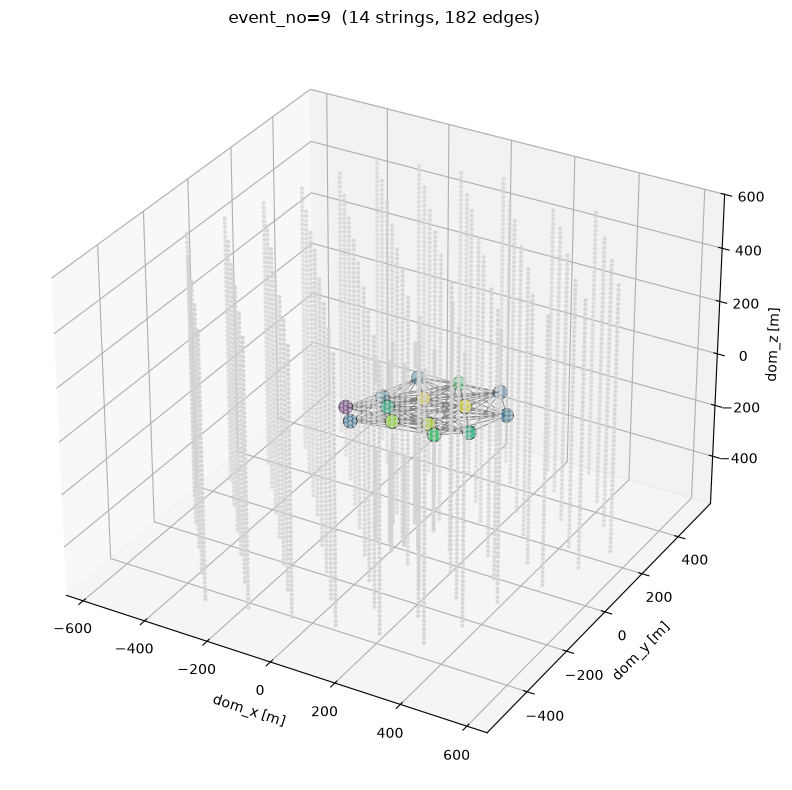

In [38]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401, registers 3d projection

XYZ_SCALE = 500.0  # must match event_to_string_graph

eid, g = graphs[2]
x = g.x.numpy()
edge_index = g.edge_index.numpy()

# de-normalize hit-string x/y; z_centroid (col 2) is charge-weighted z per string
str_x_real = x[:, 0] * XYZ_SCALE
str_y_real = x[:, 1] * XYZ_SCALE
str_z_real = x[:, 2] * XYZ_SCALE

# full detector geometry for context (every DOM, not just centroids)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(geo["dom_x"], geo["dom_y"], geo["dom_z"],
           color="lightgray", s=4, alpha=1, zorder=1, label="all DOMs")

# edges between hit strings
for src, dst in edge_index.T:
    ax.plot([str_x_real[src], str_x_real[dst]],
             [str_y_real[src], str_y_real[dst]],
             [str_z_real[src], str_z_real[dst]],
             color="gray", lw=0.7, alpha=0.6, zorder=2)

# hit strings, colored by q_log (col 6), sized by n_doms (col 7) if you want extra info
sc1 = ax.scatter(str_x_real, str_y_real, str_z_real, c=x[:, 6], cmap="viridis",
                 s=100, zorder=3, edgecolor="black", linewidth=0.5)

# fig.colorbar(sc1, ax=ax, label="q_log", shrink=0.6, pad=0.1)
# sc = ax.scatter(x_raw, y_raw, z_raw, c=np.log1p(q_raw), cmap="plasma",
#                  s=25, zorder=2, alpha=0.9)

# fig.colorbar(sc, ax=ax, label="log1p(charge)", shrink=0.6, pad=0.1)
ax.set_xlabel("dom_x [m]")
ax.set_ylabel("dom_y [m]")
ax.set_zlabel("dom_z [m]")
ax.set_title(f"event_no={eid}  ({x.shape[0]} strings, {edge_index.shape[1]} edges)")
plt.tight_layout()
plt.show()

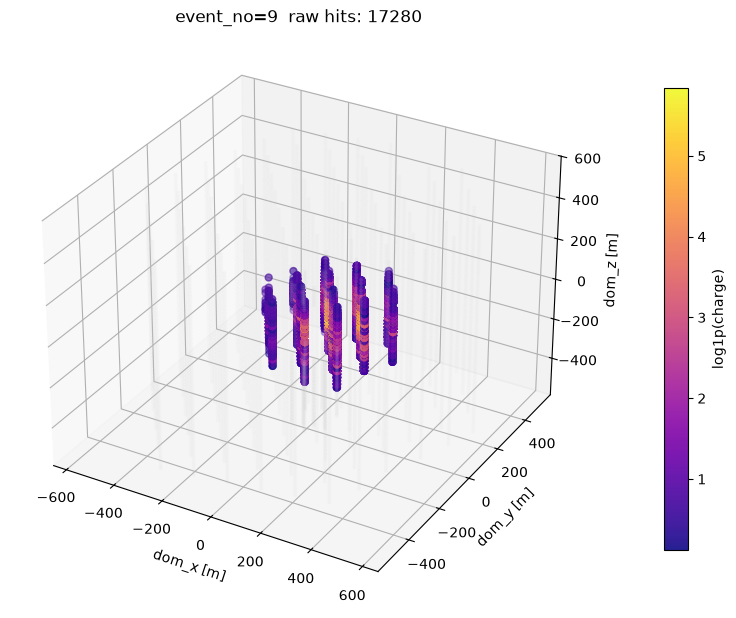

In [32]:
def get_raw_event(db_path, target_event_no):
    for eid, rows, meta in stream_events_with_truth(db_path):
        if eid == target_event_no:
            return np.array(rows, dtype=object), meta
    raise ValueError(f"event_no={target_event_no} not found in {db_path}")

rows_raw, meta_raw = get_raw_event(nutau_db, eid)  # eid from graphs[2] above

x_raw = rows_raw[:, 1].astype(float)
y_raw = rows_raw[:, 2].astype(float)
z_raw = rows_raw[:, 3].astype(float)
t_raw = rows_raw[:, 4].astype(float)
q_raw = rows_raw[:, 5].astype(float)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# full detector geometry, faint
ax.scatter(geo["dom_x"], geo["dom_y"], geo["dom_z"],
           color="lightgray", s=4, alpha=0.3, zorder=1, label="all DOMs")

# raw hits, colored by charge (log scale since charge is typically long-tailed)
sc = ax.scatter(x_raw, y_raw, z_raw, c=np.log1p(q_raw), cmap="plasma",
                 s=25, zorder=2, alpha=0.9)

fig.colorbar(sc, ax=ax, label="log1p(charge)", shrink=0.6, pad=0.1)
ax.set_xlabel("dom_x [m]")
ax.set_ylabel("dom_y [m]")
ax.set_zlabel("dom_z [m]")
ax.set_title(f"event_no={eid}  raw hits: {len(q_raw)}")
plt.tight_layout()
plt.show()

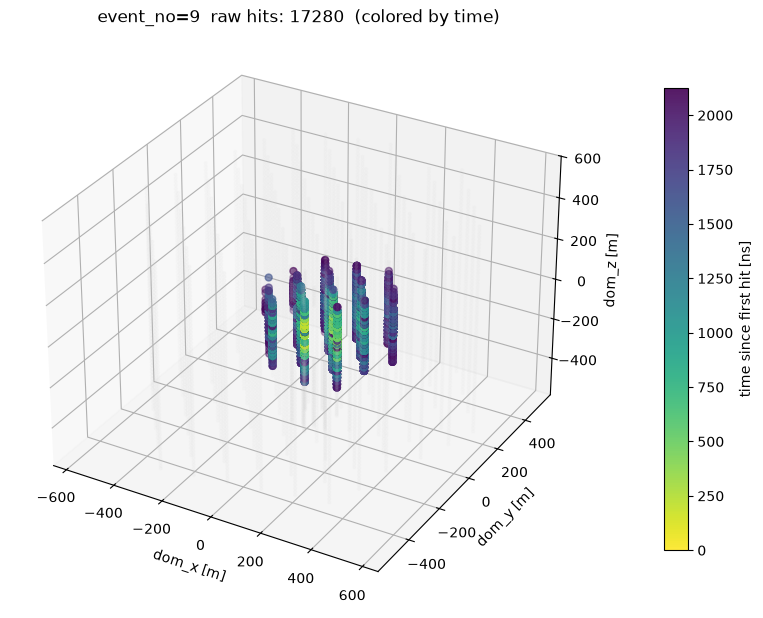

In [33]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# full detector geometry, faint
ax.scatter(geo["dom_x"], geo["dom_y"], geo["dom_z"],
           color="lightgray", s=4, alpha=0.3, zorder=1, label="all DOMs")

# raw hits, colored by relative hit time (t0-subtracted)
t_rel = t_raw - t_raw.min()

sc = ax.scatter(x_raw, y_raw, z_raw, c=t_rel, cmap="viridis_r",
                 s=25, zorder=2, alpha=0.9)

fig.colorbar(sc, ax=ax, label="time since first hit [ns]", shrink=0.6, pad=0.1)
ax.set_xlabel("dom_x [m]")
ax.set_ylabel("dom_y [m]")
ax.set_zlabel("dom_z [m]")
ax.set_title(f"event_no={eid}  raw hits: {len(q_raw)}  (colored by time)")
plt.tight_layout()
plt.show()

In [ ]:
# import matplotlib.animation as animation

# def make_shower_gif(x, y, z, t, q, geo, eid, out_path="shower_arrival.gif",
#                      n_frames=60, fps=12, trail=True, cmap="plasma"):
#     """
#     Animate hits appearing over time (IceCube-style shower arrival).
#     trail=True keeps already-fired DOMs visible (faded); False shows only
#     the current time-slice.
#     """
#     t_rel = t - t.min()
#     t_max = np.percentile(t_rel, 98)  # clip outlier late hits so animation isn't mostly empty
#     frame_edges = np.linspace(0, t_max, n_frames + 1)

#     q_norm = np.log1p(q)
#     q_norm = (q_norm - q_norm.min()) / (q_norm.max() - q_norm.min() + 1e-9)
#     sizes = 15 + 60 * q_norm  # size scales with charge

#     fig = plt.figure(figsize=(7, 7))
#     ax = fig.add_subplot(111, projection="3d")

#     ax.scatter(geo["dom_x"], geo["dom_y"], geo["dom_z"],
#                color="lightgray", s=3, alpha=0.2, zorder=1)

#     scat = ax.scatter([], [], [], c=[], cmap=cmap, vmin=0, vmax=t_max,
#                        s=[], zorder=2, edgecolor="black", linewidth=0.3)

#     ax.set_xlabel("dom_x [m]")
#     ax.set_ylabel("dom_y [m]")
#     ax.set_zlabel("dom_z [m]")
#     ax.set_xlim(geo["dom_x"].min(), geo["dom_x"].max())
#     ax.set_ylim(geo["dom_y"].min(), geo["dom_y"].max())
#     ax.set_zlim(geo["dom_z"].min(), geo["dom_z"].max())
#     title = ax.set_title(f"event_no={eid}  t=0 ns")

#     cbar = fig.colorbar(scat, ax=ax, shrink=0.6, pad=0.1, label="hit time [ns]")

#     def update(frame):
#         t_cutoff = frame_edges[frame + 1]

#         if trail:
#             mask = t_rel <= t_cutoff
#         else:
#             t_lo = frame_edges[frame]
#             mask = (t_rel > t_lo) & (t_rel <= t_cutoff)

#         pts = np.column_stack([x[mask], y[mask], z[mask]])
#         scat._offsets3d = (pts[:, 0], pts[:, 1], pts[:, 2]) if len(pts) else ([], [], [])
#         scat.set_array(t_rel[mask])
#         scat.set_sizes(sizes[mask] if len(pts) else np.array([]))
#         title.set_text(f"event_no={eid}  t={t_cutoff:.0f} ns")
#         return scat, title

#     anim = animation.FuncAnimation(fig, update, frames=n_frames, blit=False)
#     anim.save(out_path, writer=animation.PillowWriter(fps=fps))
#     plt.close(fig)
#     print(f"Saved {out_path}")


# # raw hit version
# make_shower_gif(x_raw, y_raw, z_raw, t_raw, q_raw, geo, eid,
#                  out_path="raw_shower_arrival.gif", n_frames=60, fps=12, trail=True)

Saved raw_shower_arrival.gif


In [ ]:
# eid_g, g = graphs[2]
# x_g = g.x.numpy()

# str_x_real = x_g[:, 0] * XYZ_SCALE
# str_y_real = x_g[:, 1] * XYZ_SCALE
# str_z_real = x_g[:, 2] * XYZ_SCALE
# t_first_real = x_g[:, 10] * 500.0  # t_scale used in event_to_string_graph
# q_log_col = x_g[:, 6]

# make_shower_gif(str_x_real, str_y_real, str_z_real, t_first_real,
#                  np.expm1(q_log_col),  # undo log1p to get back to a charge-like quantity for sizing
#                  geo, eid_g, out_path="graph_shower_arrival.gif",
#                  n_frames=40, fps=8, trail=True)

Saved graph_shower_arrival.gif


In [ ]:
import os
os.environ["NUMBA_THREADING_LAYER"] = "workqueue"  # avoid TBB/OMP conflicts with torch
os.environ["OMP_NUM_THREADS"] = "1"

import umap
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from hybrid_common import PCA_FEATURE_NAMES

feat_matrix = df_all[PCA_FEATURE_NAMES].values
scaler = StandardScaler()
feat_scaled = scaler.fit_transform(feat_matrix)

labels = df_all["label"].values
n_hits = df_all["n_hits"].values

# ---- UMAP ----
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=42)
embedding_umap = reducer.fit_transform(feat_scaled)

# ---- t-SNE ----
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
embedding_tsne = tsne.fit_transform(feat_scaled)

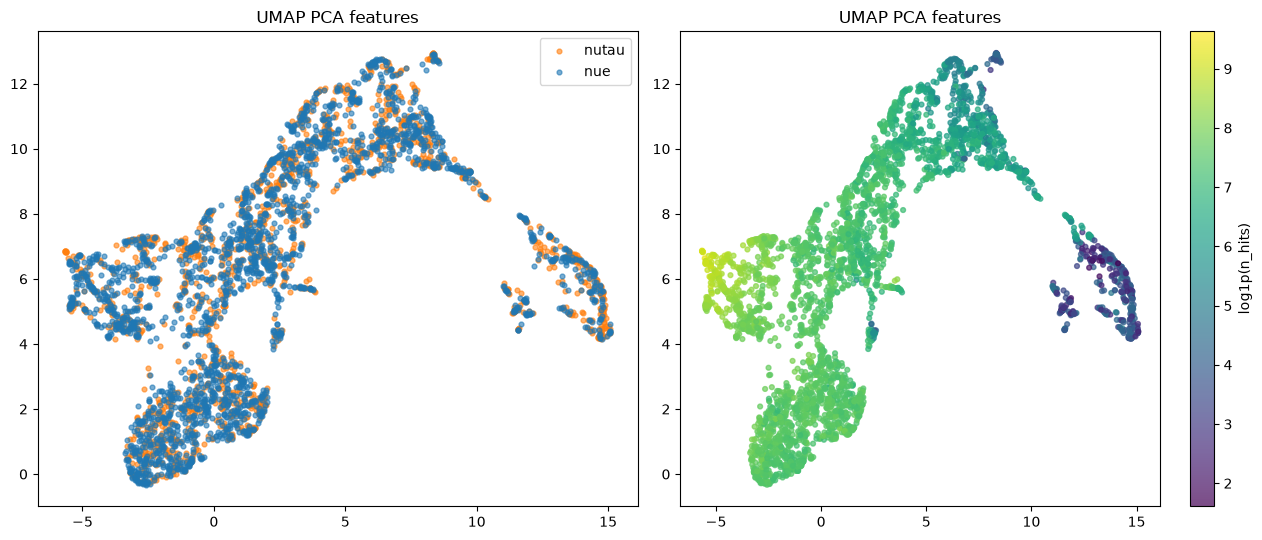

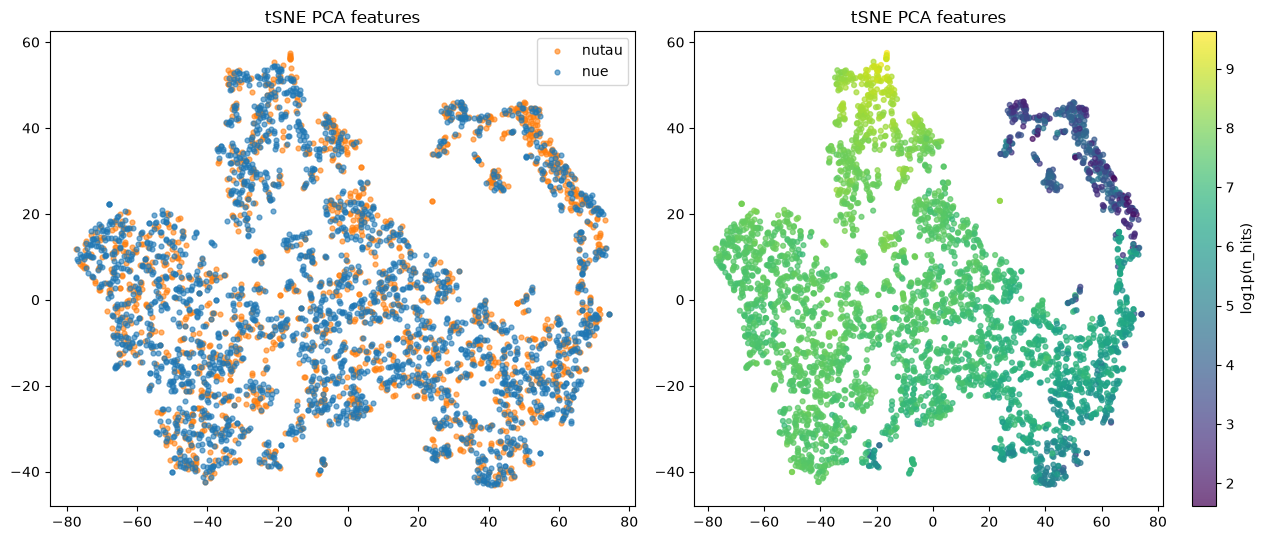

In [46]:

def plot_embedding(embedding, title, color_by_size=False):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    # colored by class
    for lab, color in zip(["nutau", "nue"], ["tab:orange", "tab:blue"]):
        mask = labels == lab
        axes[0].scatter(embedding[mask, 0], embedding[mask, 1],
                         s=12, alpha=0.6, label=lab, color=color)
    axes[0].set_title(f"{title}")
    axes[0].legend()

    # colored by event size (n_hits), to check if this drives the structure
    sc = axes[1].scatter(embedding[:, 0], embedding[:, 1],
                          c=np.log1p(n_hits), cmap="viridis", s=12, alpha=0.7)
    fig.colorbar(sc, ax=axes[1], label="log1p(n_hits)")
    axes[1].set_title(f"{title}")

    plt.tight_layout()
    # plt.savefig(f"{title.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()


plot_embedding(embedding_umap, "UMAP PCA features")
plot_embedding(embedding_tsne, "tSNE PCA features")

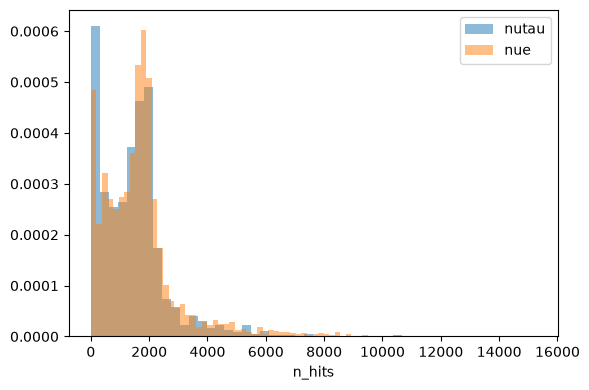

In [35]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(df_tau["n_hits"], bins=50, alpha=0.5, label="nutau", density=True)
ax.hist(df_nue["n_hits"], bins=50, alpha=0.5, label="nue", density=True)
ax.set_xlabel("n_hits"); ax.legend()
plt.tight_layout(); plt.show()

Loaded 1785 tau truth rows from 20 files
count   1782.0000
mean      11.7339
std      105.1436
min        0.0000
25%        0.2693
50%        2.0557
75%        6.3128
max     3060.5337
dtype: float64


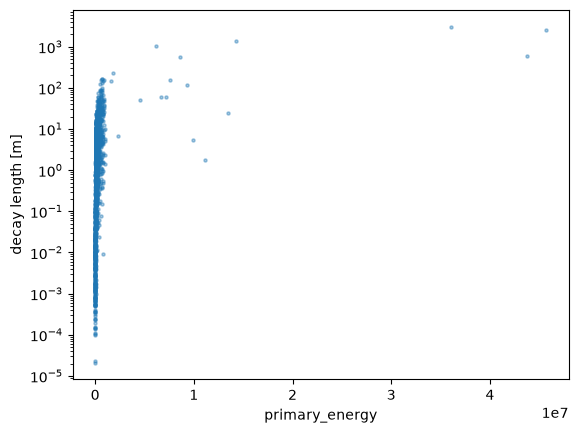

In [41]:
import sqlite3, glob, os

tau_db_paths = sorted(glob.glob(os.path.join(NUTAU_DIR, "nutau_gemini_ftp_65TeV_*.db")))
conn = sqlite3.connect(tau_db_paths[0])

df_truth_tau = pd.read_sql_query(
    "SELECT event_no, tau_prod_vertex_x, tau_prod_vertex_y, tau_prod_vertex_z, "
    "tau_dec_vertex_x, tau_dec_vertex_y, tau_dec_vertex_z, primary_energy FROM truth;",
    conn
)
conn.close()

dfs = []
for p in tau_db_paths[:20]:  # match n_files used elsewhere
    c = sqlite3.connect(p)
    df_p = pd.read_sql_query(
        "SELECT event_no, tau_prod_vertex_x, tau_prod_vertex_y, tau_prod_vertex_z, "
        "tau_dec_vertex_x, tau_dec_vertex_y, tau_dec_vertex_z, primary_energy FROM truth;",
        c
    )
    dfs.append(df_p)
    c.close()

df_truth_tau = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(df_truth_tau)} tau truth rows from {len(dfs)} files")

# df_truth_tau = pd.read_sql_query("SELECT event_no, tau_prod_vertex_x, tau_prod_vertex_y, tau_prod_vertex_z, tau_dec_vertex_x, tau_dec_vertex_y, tau_dec_vertex_z, primary_energy FROM truth;", conn)  # from a tau db

decay_length = np.sqrt(
    (df_truth_tau["tau_dec_vertex_x"] - df_truth_tau["tau_prod_vertex_x"])**2 +
    (df_truth_tau["tau_dec_vertex_y"] - df_truth_tau["tau_prod_vertex_y"])**2 +
    (df_truth_tau["tau_dec_vertex_z"] - df_truth_tau["tau_prod_vertex_z"])**2
)
print(decay_length.describe())

fig, ax = plt.subplots()
ax.scatter(df_truth_tau["primary_energy"], decay_length, s=5, alpha=0.4)
ax.set_xlabel("primary_energy")
ax.set_ylabel("decay length [m]")
ax.set_yscale("log")
plt.show()

In [47]:
df_truth_tau

,event_no,tau_prod_vertex_x,tau_prod_vertex_y,tau_prod_vertex_z,tau_dec_vertex_x,tau_dec_vertex_y,tau_dec_vertex_z,primary_energy
0,0,354.5191,385.2479,10.6088,65.7252,138.5960,-960.1503,6149698.9603
1,8,-80.9122,-239.9238,-465.5266,221.0510,147.2998,-826.1065,43728391.3091
2,9,-78.7321,171.1073,-242.0759,-78.4044,315.9364,-306.1063,7593127.1314
3,12,360.5589,367.7712,-306.9366,341.9547,404.7049,-417.6660,9340916.8237
4,19,469.9746,58.0691,-402.3001,501.0432,98.3969,-412.2689,4581795.9549
...,...,...,...,...,...,...,...,...
1780,327,-442.5231,29.6918,278.9388,-445.6532,32.9565,275.2212,432589.0330
1781,331,92.6677,-334.5290,341.3133,91.9164,-333.9117,340.6343,251502.5894
1782,334,104.7357,-210.7602,-458.2633,104.0188,-205.4198,-463.7496,208787.8658
1783,335,-252.7118,348.3779,120.2057,-250.5258,342.8514,120.2037,123173.9090


In [42]:
long_decay_mask = decay_length > 50  # roughly IceCube string spacing
print(f"Events with decay length > 50m: {long_decay_mask.sum()} / {len(decay_length)} ({100*long_decay_mask.mean():.2f}%)")

Events with decay length > 50m: 42 / 1785 (2.35%)


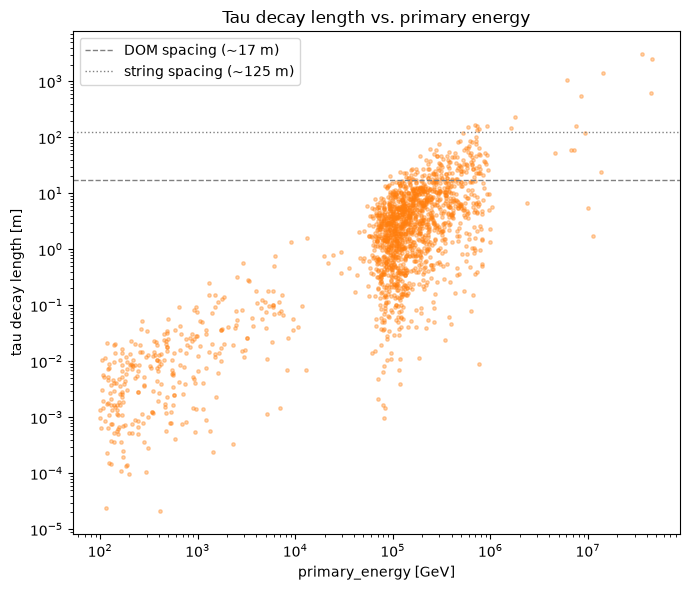

In [43]:
fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(df_truth_tau["primary_energy"], decay_length,
                 s=6, alpha=0.35, color="tab:orange")

ax.set_xlabel("primary_energy [GeV]")  # confirm units against your truth table docs
ax.set_ylabel("tau decay length [m]")
ax.set_xscale("log")
ax.set_yscale("log")

# reference lines: IceCube spatial resolution scales
ax.axhline(17, color="gray", linestyle="--", lw=1, label="DOM spacing (~17 m)")
ax.axhline(125, color="gray", linestyle=":", lw=1, label="string spacing (~125 m)")

ax.legend()
ax.set_title("Tau decay length vs. primary energy")
plt.tight_layout()
plt.show()

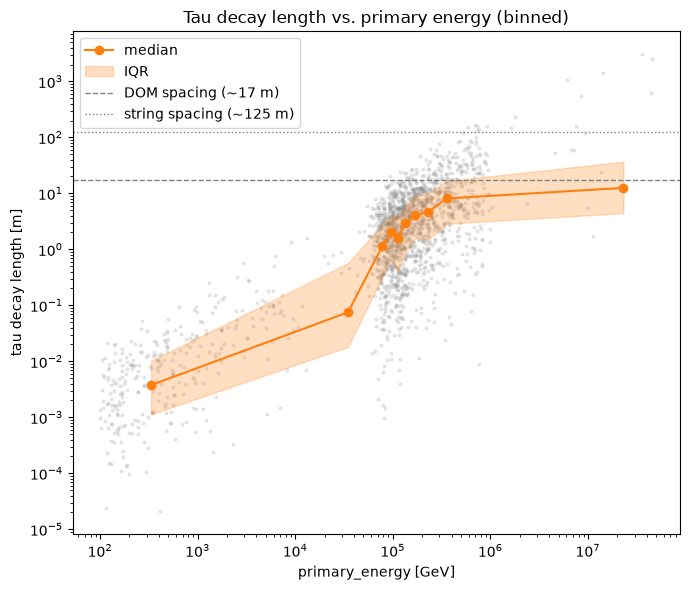

In [44]:
df_dl = pd.DataFrame({
    "primary_energy": df_truth_tau["primary_energy"],
    "decay_length": decay_length,
}).dropna()

df_dl["energy_bin"] = pd.qcut(df_dl["primary_energy"], q=10, duplicates="drop")

summary = df_dl.groupby("energy_bin")["decay_length"].agg(["median", 
                                                              lambda x: x.quantile(0.25),
                                                              lambda x: x.quantile(0.75)])
summary.columns = ["median", "q25", "q75"]
bin_centers = [interval.mid for interval in summary.index]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_dl["primary_energy"], df_dl["decay_length"], s=4, alpha=0.15, color="gray", zorder=1)
ax.plot(bin_centers, summary["median"], color="tab:orange", marker="o", zorder=2, label="median")
ax.fill_between(bin_centers, summary["q25"], summary["q75"], color="tab:orange", alpha=0.25, label="IQR")

ax.axhline(17, color="gray", linestyle="--", lw=1, label="DOM spacing (~17 m)")
ax.axhline(125, color="gray", linestyle=":", lw=1, label="string spacing (~125 m)")

ax.set_xlabel("primary_energy [GeV]")
ax.set_ylabel("tau decay length [m]")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_title("Tau decay length vs. primary energy (binned)")
plt.tight_layout()
plt.show()

Loaded 1785 tau truth+reco rows from 20 files
primary_energy:          min=100.29 max=45690784.95 GeV
cascade_reco_energy_gev: min=65031.12 max=4665043921542062.00 GeV
fraction primary_energy < 65 TeV:     0.190
fraction cascade_reco_energy < 65 TeV: 0.000


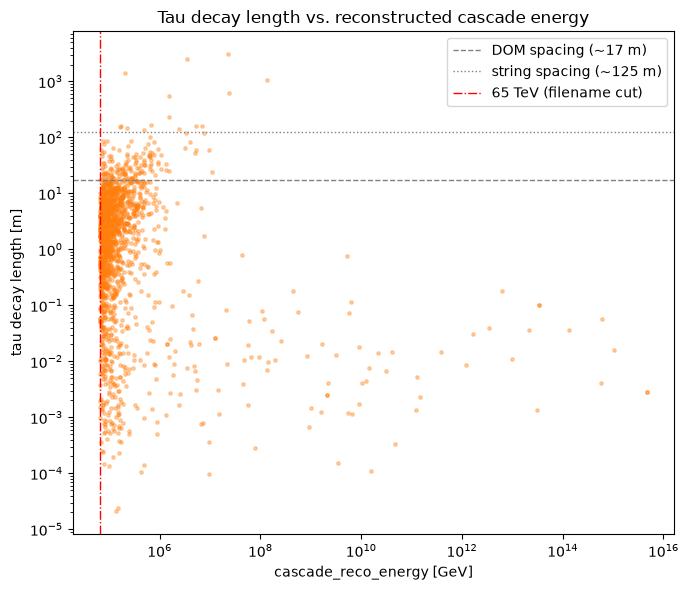

In [48]:
dfs = []
for p in tau_db_paths[:20]:
    c = sqlite3.connect(p)
    df_p = pd.read_sql_query(
        "SELECT t.event_no, t.tau_prod_vertex_x, t.tau_prod_vertex_y, t.tau_prod_vertex_z, "
        "t.tau_dec_vertex_x, t.tau_dec_vertex_y, t.tau_dec_vertex_z, t.primary_energy, "
        "r.cascade_reco_energy_tev "
        "FROM truth t JOIN reco r ON t.event_no = r.event_no;",
        c
    )
    dfs.append(df_p)
    c.close()

df_truth_tau = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(df_truth_tau)} tau truth+reco rows from {len(dfs)} files")

decay_length = np.sqrt(
    (df_truth_tau["tau_dec_vertex_x"] - df_truth_tau["tau_prod_vertex_x"])**2 +
    (df_truth_tau["tau_dec_vertex_y"] - df_truth_tau["tau_prod_vertex_y"])**2 +
    (df_truth_tau["tau_dec_vertex_z"] - df_truth_tau["tau_prod_vertex_z"])**2
)

# cascade_reco_energy_tev is in TeV per its name -- convert to GeV for direct comparison with primary_energy
cascade_reco_energy_gev = df_truth_tau["cascade_reco_energy_tev"] * 1000.0

print(f"primary_energy:          min={df_truth_tau['primary_energy'].min():.2f} max={df_truth_tau['primary_energy'].max():.2f} GeV")
print(f"cascade_reco_energy_gev: min={cascade_reco_energy_gev.min():.2f} max={cascade_reco_energy_gev.max():.2f} GeV")
print(f"fraction primary_energy < 65 TeV:     {(df_truth_tau['primary_energy'] < 65000).mean():.3f}")
print(f"fraction cascade_reco_energy < 65 TeV: {(cascade_reco_energy_gev < 65000).mean():.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(cascade_reco_energy_gev, decay_length, s=6, alpha=0.35, color="tab:orange")
ax.set_xlabel("cascade_reco_energy [GeV]")
ax.set_ylabel("tau decay length [m]")
ax.set_xscale("log")
ax.set_yscale("log")
ax.axhline(17, color="gray", linestyle="--", lw=1, label="DOM spacing (~17 m)")
ax.axhline(125, color="gray", linestyle=":", lw=1, label="string spacing (~125 m)")
ax.axvline(65000, color="red", linestyle="-.", lw=1, label="65 TeV (filename cut)")
ax.legend()
ax.set_title("Tau decay length vs. reconstructed cascade energy")
plt.tight_layout()
plt.savefig("decay_length_vs_reco_energy.png", dpi=150)
plt.show()

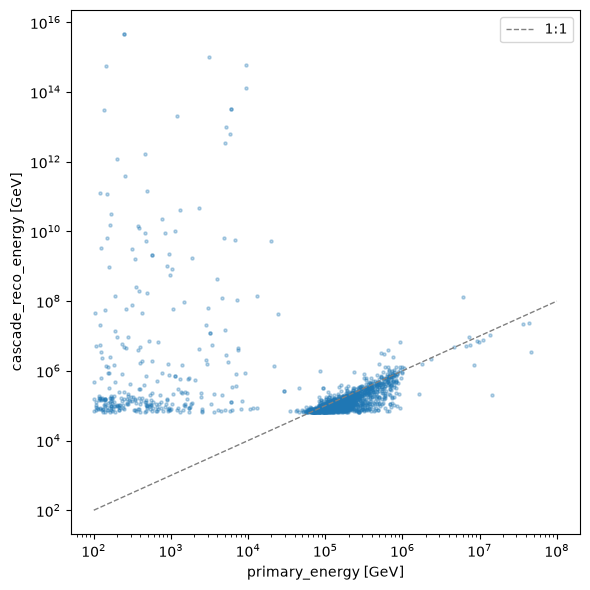

In [50]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df_truth_tau["primary_energy"], cascade_reco_energy_gev, s=5, alpha=0.3)
ax.plot([1e2, 1e8], [1e2, 1e8], color="gray", linestyle="--", lw=1, label="1:1")
ax.set_xlabel("primary_energy [GeV]")
ax.set_ylabel("cascade_reco_energy [GeV]")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

In [55]:
n_below_primary = 0
n_below_reco = 0
n_total = 0

for p in tau_db_paths:
    c = sqlite3.connect(p)
    df_join = pd.read_sql_query(
        "SELECT t.primary_energy, r.cascade_reco_energy_tev "
        "FROM truth t JOIN reco r ON t.event_no = r.event_no;",
        c
    )
    c.close()

    n_total += len(df_join)
    n_below_primary += (df_join["primary_energy"] < 65000).sum()
    n_below_reco += (df_join["cascade_reco_energy_tev"] * 1000.0 < 65000).sum()

print(f"total events: {n_total}")
print(f"below 65 TeV by primary_energy:     {n_below_primary} ({100*n_below_primary/n_total:.1f}%)")
print(f"below 65 TeV by cascade_reco_energy: {n_below_reco} ({100*n_below_reco/n_total:.1f}%)")

total events: 10809
below 65 TeV by primary_energy:     503 (4.7%)
below 65 TeV by cascade_reco_energy: 0 (0.0%)


event_no=3  primary_energy=780.86 GeV  file=nutau_gemini_ftp_65TeV_lowerbound_skimmed_chunk_022858.000083_0000.db_train.db
event_no=6  primary_energy=482.17 GeV  file=nutau_gemini_ftp_65TeV_lowerbound_skimmed_chunk_022858.000083_0000.db_train.db
event_no=7  primary_energy=323.31 GeV  file=nutau_gemini_ftp_65TeV_lowerbound_skimmed_chunk_022858.000083_0000.db_train.db
event_no=8  primary_energy=839.46 GeV  file=nutau_gemini_ftp_65TeV_lowerbound_skimmed_chunk_022858.000083_0000.db_train.db
event_no=12  primary_energy=165.72 GeV  file=nutau_gemini_ftp_65TeV_lowerbound_skimmed_chunk_022858.000083_0000.db_train.db


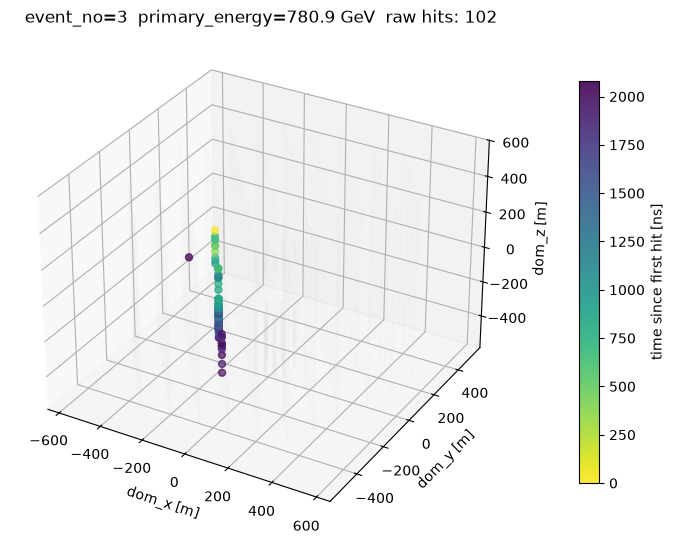

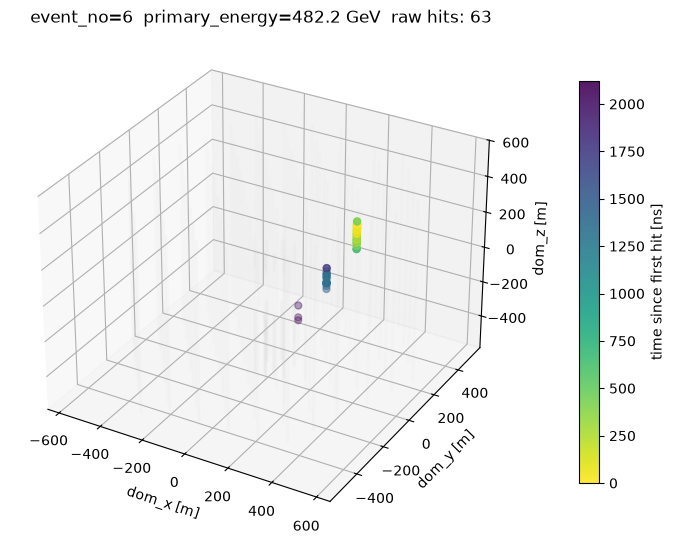

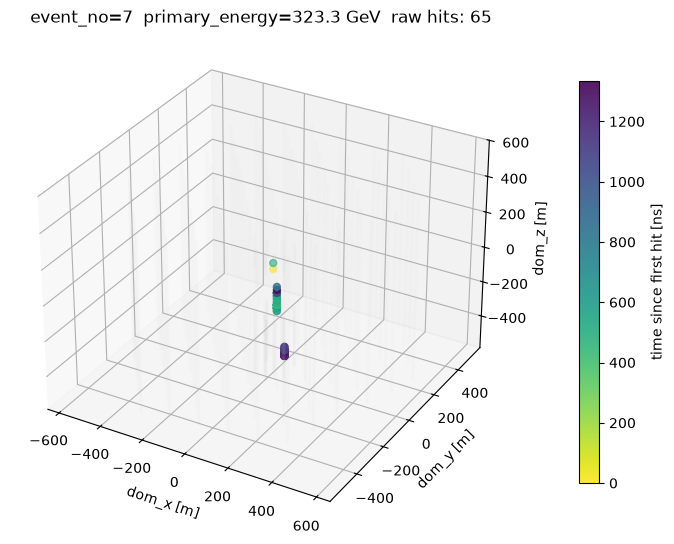

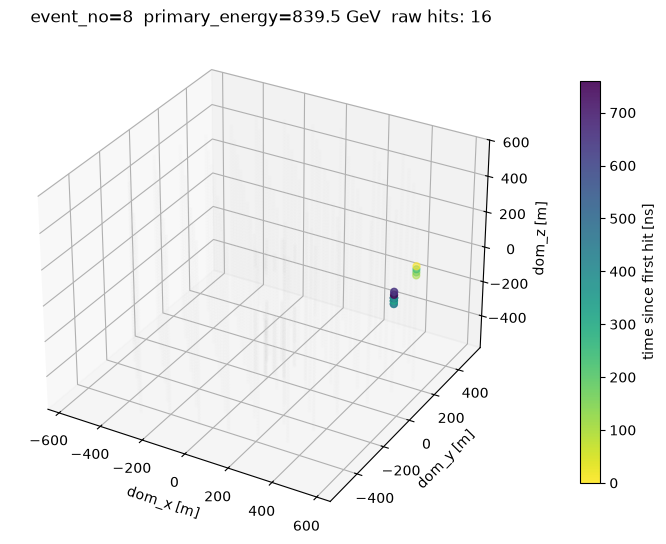

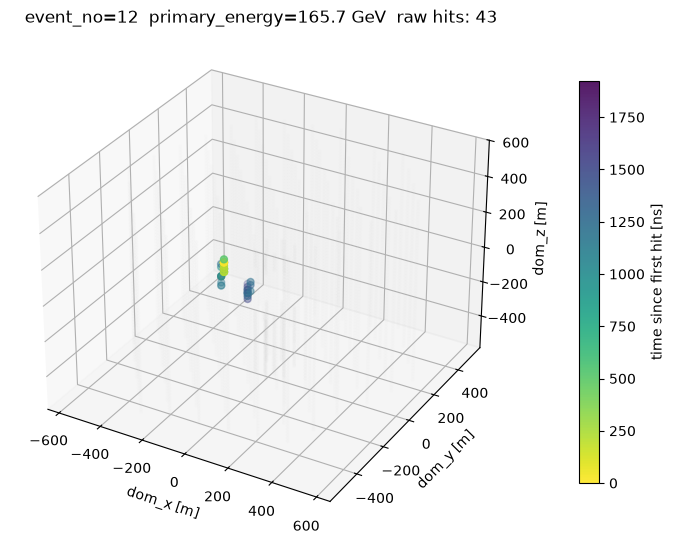

In [54]:
import sqlite3

def find_low_energy_events(db_paths, max_energy_gev=1000.0, n_events=5):
    """Scan tau files for the first n_events with primary_energy < max_energy_gev."""
    found = []
    for p in db_paths:
        if len(found) >= n_events:
            break
        c = sqlite3.connect(p)
        remaining = n_events - len(found)
        df_t = pd.read_sql_query(
            "SELECT event_no, primary_energy FROM truth WHERE primary_energy < ? LIMIT ?;",
            c, params=(max_energy_gev, remaining)
        )
        c.close()
        for _, row in df_t.iterrows():
            found.append((p, int(row["event_no"]), float(row["primary_energy"])))
    return found


low_energy_events = find_low_energy_events(tau_db_paths, max_energy_gev=1000.0, n_events=5)
for p, eid, energy in low_energy_events:
    print(f"event_no={eid}  primary_energy={energy:.2f} GeV  file={os.path.basename(p)}")

for i, (p, eid, energy) in enumerate(low_energy_events):
    rows, meta = get_raw_event(p, eid)

    x_e = rows[:, 1].astype(float)
    y_e = rows[:, 2].astype(float)
    z_e = rows[:, 3].astype(float)
    t_e = rows[:, 4].astype(float)
    q_e = rows[:, 5].astype(float)
    t_rel = t_e - t_e.min()

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(geo["dom_x"], geo["dom_y"], geo["dom_z"],
               color="lightgray", s=3, alpha=0.2, zorder=1)

    sc = ax.scatter(x_e, y_e, z_e, c=t_rel, cmap="viridis_r",
                     s=25, zorder=2, alpha=0.9)

    fig.colorbar(sc, ax=ax, label="time since first hit [ns]", shrink=0.6, pad=0.1)
    ax.set_xlabel("dom_x [m]")
    ax.set_ylabel("dom_y [m]")
    ax.set_zlabel("dom_z [m]")
    ax.set_title(f"event_no={eid}  primary_energy={energy:.1f} GeV  raw hits: {len(q_e)}")

    # set_axes_equal_3d(ax)
    plt.tight_layout()
    # plt.savefig(f"low_energy_event_{i}_eid{eid}.png", dpi=150)
    plt.show()

In [45]:
print(f"primary_energy min: {df_truth_tau['primary_energy'].min():.2f} GeV")
print(f"primary_energy max: {df_truth_tau['primary_energy'].max():.2f} GeV")
print(f"fraction below 65 TeV (65000 GeV): {(df_truth_tau['primary_energy'] < 65000).mean():.3f}")

primary_energy min: 100.29 GeV
primary_energy max: 45690784.95 GeV
fraction below 65 TeV (65000 GeV): 0.190


/mnt/scratch/baburish/doublepulse/gnn/event-nn-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


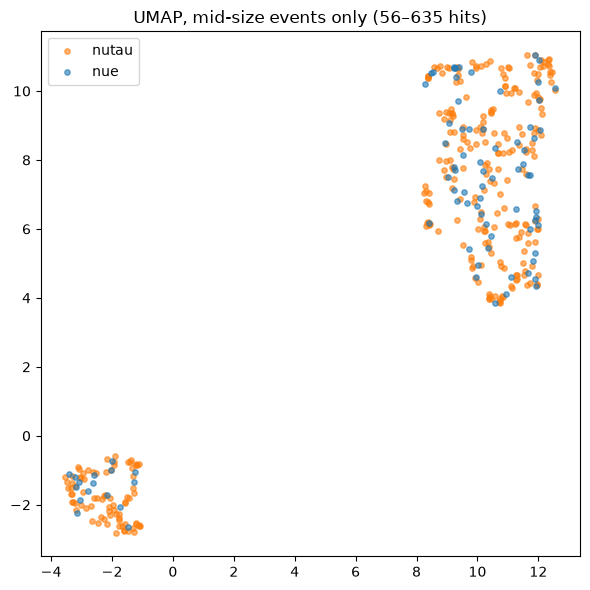

In [19]:
mask_mid = (df_all["n_hits"] > 56) & (df_all["n_hits"] <= 635)
df_mid = df_all[mask_mid].reset_index(drop=True)

feat_mid_scaled = StandardScaler().fit_transform(df_mid[PCA_FEATURE_NAMES].values)

reducer_mid = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_mid = reducer_mid.fit_transform(feat_mid_scaled)

fig, ax = plt.subplots(figsize=(6, 6))
for lab, color in zip(["nutau", "nue"], ["tab:orange", "tab:blue"]):
    mask = df_mid["label"] == lab
    ax.scatter(embedding_mid[mask, 0], embedding_mid[mask, 1],
               s=15, alpha=0.6, label=lab, color=color)
ax.set_title("UMAP, mid-size events only (56–635 hits)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
class HybridGNNClassifier(nn.Module):
    def __init__(self, gnn_hidden_dim=64, pca_dim=13, fusion_dim=32):
        super().__init__()

        self.node_mlp = nn.Sequential(
            nn.Linear(N_GNN_FEATURES, gnn_hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(gnn_hidden_dim),
        )

        self.conv1 = TransformerConv(gnn_hidden_dim,     gnn_hidden_dim, heads=4)
        self.conv2 = TransformerConv(gnn_hidden_dim * 4, gnn_hidden_dim, heads=4)
        self.conv3 = TransformerConv(gnn_hidden_dim * 4, gnn_hidden_dim, heads=4)

        self.bn1 = nn.BatchNorm1d(gnn_hidden_dim * 4)
        self.bn2 = nn.BatchNorm1d(gnn_hidden_dim * 4)
        self.bn3 = nn.BatchNorm1d(gnn_hidden_dim * 4)
        self.act = nn.ReLU()
        self.drop_gnn = nn.Dropout(0.4)

        # --- virtual node additions ---
        # vn_embedding: learnable init, broadcast to nodes before conv1 (dim = gnn_hidden_dim)
        self.vn_embedding_init = nn.Parameter(torch.zeros(1, gnn_hidden_dim))

        # vn update MLPs: pool node features (post-conv dim = gnn_hidden_dim*4) + prior vn state -> new vn state
        self.vn_mlp1 = nn.Sequential(
            nn.Linear(gnn_hidden_dim * 4, gnn_hidden_dim * 4),
            nn.ReLU(),
            nn.BatchNorm1d(gnn_hidden_dim * 4),
            nn.Dropout(0.4),
        )
        self.vn_mlp2 = nn.Sequential(
            nn.Linear(gnn_hidden_dim * 4, gnn_hidden_dim * 4),
            nn.ReLU(),
            nn.BatchNorm1d(gnn_hidden_dim * 4),
            nn.Dropout(0.4),
        )
        # projects vn from gnn_hidden_dim (after conv1's input stage) up to gnn_hidden_dim*4
        # to match conv2/conv3 input width when broadcasting
        self.vn_proj1 = nn.Linear(gnn_hidden_dim, gnn_hidden_dim * 4)
        # --- end virtual node additions ---

        gnn_output_dim = gnn_hidden_dim * 4 + 1

        self.pca_mlp = nn.Sequential(
            nn.Linear(pca_dim, fusion_dim),
            nn.ReLU(),
            nn.BatchNorm1d(fusion_dim),
            nn.Dropout(0.3),
        )
        pca_output_dim = fusion_dim

        self.fusion = nn.Sequential(
            nn.Linear(gnn_output_dim + pca_output_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, data, pca_features):
        from torch_geometric.nn import global_add_pool

        x, edge_index, batch = data.x, data.edge_index, data.batch
        num_graphs = int(batch.max().item()) + 1

        x = self.node_mlp(x)  # (n_nodes, gnn_hidden_dim)

        # init virtual node state, one per graph in the batch
        vn = self.vn_embedding_init.expand(num_graphs, -1)  # (num_graphs, gnn_hidden_dim)

        # --- layer 1 ---
        x = x + vn[batch]  # broadcast vn to every node in its graph
        x = self.drop_gnn(self.act(self.bn1(self.conv1(x, edge_index))))
        vn = self.vn_proj1(vn)                         # lift vn to conv1's output width
        vn_pooled = global_add_pool(x, batch)           # (num_graphs, gnn_hidden_dim*4)
        vn = self.vn_mlp1(vn_pooled + vn)                # residual update

        # --- layer 2 ---
        x = x + vn[batch]
        x = self.drop_gnn(self.act(self.bn2(self.conv2(x, edge_index))))
        vn_pooled = global_add_pool(x, batch)
        vn = self.vn_mlp2(vn_pooled + vn)

        # --- layer 3 ---
        x = x + vn[batch]
        x = self.drop_gnn(self.act(self.bn3(self.conv3(x, edge_index))))
        # no vn update needed after final layer -- its info is already folded into x

        gnn_output = global_mean_pool(x, batch)
        mean_q = global_mean_pool(data.x[:, 6], batch).unsqueeze(1)
        gnn_features = torch.cat([gnn_output, mean_q], dim=1)

        pca_output = self.pca_mlp(pca_features)

        fused = torch.cat([gnn_features, pca_output], dim=1)
        return self.fusion(fused).squeeze(-1)